# Cancel rate by feature

> **Purpose -** anchor for analysis and the plausibility baseline for SHAP/coefficient reading. For every feature I report the plain observed cancellation rate per level / bucket to get an idea about feature relevance before trainign.

- Computed on **train + val only**
- **Purely descriptive**  
- levels with n < 500 are greyed out of the headline chart


In [3]:
#  setup: project root on path, helpers, output dirs 
import sys
from pathlib import Path
_here = Path.cwd().resolve()
while not (_here / "pyproject.toml").exists() and _here != _here.parent:
    _here = _here.parent
if str(_here) not in sys.path:
    sys.path.insert(0, str(_here))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_clean_reservations
from src.features import model_feature_roster
from src import apply_stayery_style, color, figures_dir, tables_dir

warnings.filterwarnings("ignore", category=FutureWarning)
apply_stayery_style()
FIG = figures_dir() / "experiments"; FIG.mkdir(parents=True, exist_ok=True)
TAB = tables_dir() / "00_audit";     TAB.mkdir(parents=True, exist_ok=True)

TARGET = "status"          # 1 = cancelled, 0 = arrived
MIN_N_HEADLINE = 500       

# Outcome leakage Felder (Felder die nur bei Gästen befüllt sind die auch tatsächlich einchecken)
LEAKY = ["guest_country_region", "primaryGuest_preferredLanguage", "travelPurpose", "has_company", "is_repeat_company", "company_prior_bookings", "company_prior_cancel_rate"]


In [4]:
#  load + restrict to train+val 
df = load_clean_reservations().dropna(subset=[TARGET]).copy()

NUMERIC_BASE, CATEGORICAL_BASE = model_feature_roster(df)
# leaky features werden nicht in Modellen verwendet aber in deskriptiven Teilen trotzdem dargestellt
CATEGORICAL_BASE = CATEGORICAL_BASE + [c for c in
    ["guest_country_region", "primaryGuest_preferredLanguage", "travelPurpose"]
    if c in df.columns and c not in CATEGORICAL_BASE]
BINARY = [c for c in NUMERIC_BASE if df[c].dropna().nunique() <= 2]
CONTINUOUS = [c for c in NUMERIC_BASE if c not in BINARY]

BASE = float(df[TARGET].mean())
print(f"{len(df):,} bookings (train+val) | base cancel rate {BASE:.1%}")
print(f"{len(CATEGORICAL_BASE)} categoricals | {len(BINARY)} binary | {len(CONTINUOUS)} continuous")


179,349 bookings (train+val) | base cancel rate 19.8%
7 categoricals | 7 binary | 11 continuous


In [5]:
#  1) categorical + binary features: rate per level 
rows = []
for col in CATEGORICAL_BASE + BINARY:
    g = (df.groupby(df[col].astype("string"), observed=True, dropna=False)[TARGET]
           .agg(n="size", cancel_rate="mean").reset_index(names="level"))
    g.insert(0, "feature", col)
    g["share"] = g["n"] / len(df)
    g["lift_vs_base"] = g["cancel_rate"] / BASE
    rows.append(g.sort_values("cancel_rate", ascending=False))
cat_tab = pd.concat(rows, ignore_index=True)
cat_tab.to_csv(TAB / "cancel_rate_by_feature_categorical.csv", index=False)

# compact print: per feature, levels sorted by rate (n + rate + lift)
for col, g in cat_tab.groupby("feature", sort=False):
    print(f"\n== {col} ==  ({g['level'].nunique()} levels)")
    show = g[["level", "n", "share", "cancel_rate", "lift_vs_base"]].copy()
    print(show.to_string(index=False,
          formatters={"n": "{:,.0f}".format, "share": "{:.1%}".format,
                      "cancel_rate": "{:.1%}".format, "lift_vs_base": "{:.2f}x".format}))



== property_name ==  (11 levels)
                   level      n share cancel_rate lift_vs_base
 Frankfurt Sachsenhausen 24,844 13.9%       26.6%        1.34x
   Berlin Friedrichshain 26,800 14.9%       23.8%        1.20x
       Cologne Ehrenfeld 14,411  8.0%       22.6%        1.14x
            Cologne Sülz  4,971  2.8%       21.5%        1.09x
    Wolfsburg Schachtweg 13,693  7.6%       18.9%        0.96x
  Bielefeld Hauptbahnhof 43,084 24.0%       16.9%        0.85x
          Bremen Am Wall 28,519 15.9%       16.8%        0.85x
        Fürth Hallstraße    773  0.4%       16.6%        0.84x
Osnabrück Johannisstraße  7,972  4.4%       16.2%        0.82x
    Gütersloh Langer Weg 10,310  5.7%       15.3%        0.77x
        Bochum Ehrenfeld  3,972  2.2%       14.8%        0.74x

== unitGroup_name ==  (10 levels)
                   level       n share cancel_rate lift_vs_base
                   UPPER   4,846  2.7%       23.6%        1.19x
BIGGER AIRCON Not in use     145  0.1%       20

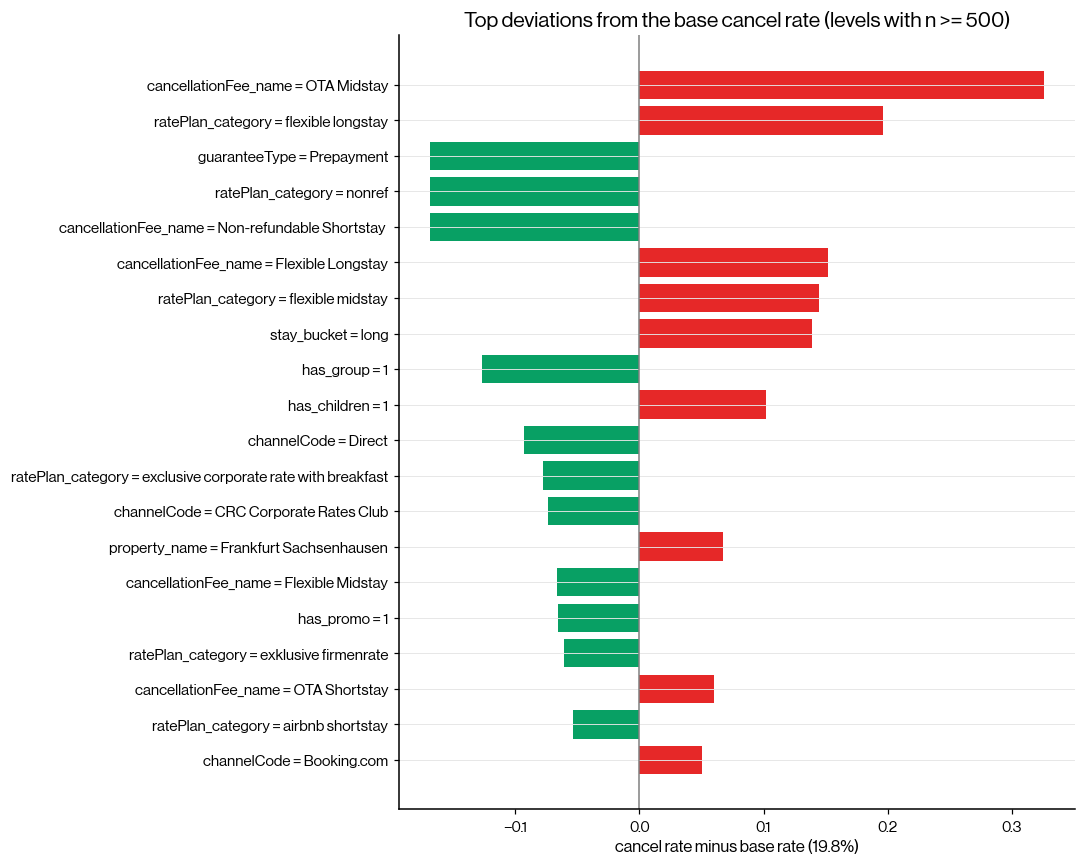

In [6]:
#  headline chart: the 20 biggest deviations from the base rate (n >= MIN_N) 
big = cat_tab[(cat_tab["n"] >= MIN_N_HEADLINE)
              & ~cat_tab["feature"].isin(LEAKY)].copy()   # Leak-Felder raus (s. §0)
big["dev"] = big["cancel_rate"] - BASE
big = big.reindex(big["dev"].abs().sort_values(ascending=False).index).head(20)
big["label"] = big["feature"] + " = " + big["level"].astype(str)

fig, ax = plt.subplots(figsize=(10, 8))
b = big.iloc[::-1]
ax.barh(b["label"], b["dev"],
        color=[color("red") if d > 0 else color("green") for d in b["dev"]])
ax.axvline(0, color="grey", lw=1)
ax.set_xlabel(f"cancel rate minus base rate ({BASE:.1%})")
ax.set_title(f"Top deviations from the base cancel rate (levels with n >= {MIN_N_HEADLINE})")
fig.tight_layout()
fig.savefig(FIG / "cancel_rate_top_deviations.png", dpi=150)
plt.show()


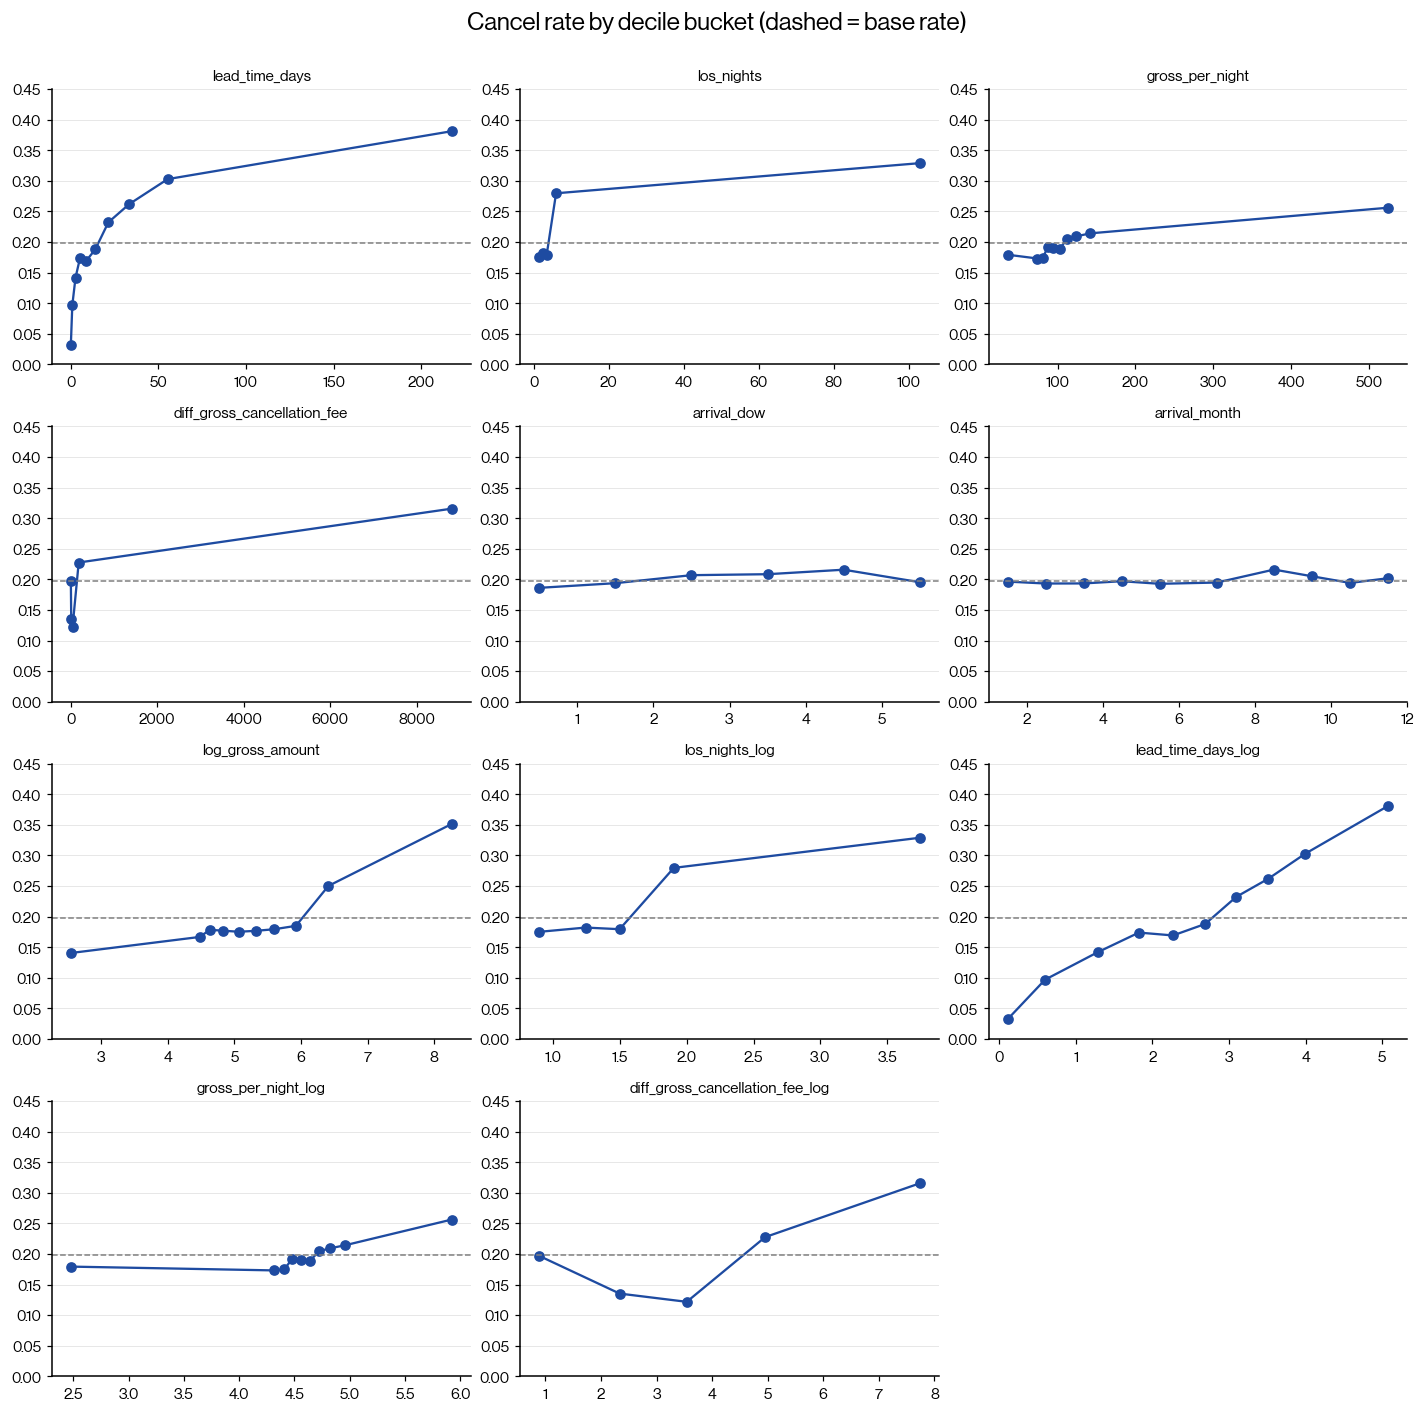

In [7]:
#  2) continuous numerics: rate per decile bucket 
rows = []
for col in CONTINUOUS:
    s = df[col].astype("float64")
    try:
        b = pd.qcut(s, 10, duplicates="drop")     # decile buckets (fewer if ties)
    except ValueError:
        continue                                   # not enough distinct values
    g = df.groupby(b, observed=True)[TARGET].agg(n="size", cancel_rate="mean").reset_index(names="bucket")
    g.insert(0, "feature", col)
    rows.append(g)
num_tab = pd.concat(rows, ignore_index=True)
num_tab.to_csv(TAB / "cancel_rate_by_feature_numeric.csv", index=False)

# small-multiples: one rate-per-bucket line per continuous feature
n = len(CONTINUOUS); ncols = 3; nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows), squeeze=False)
for ax, col in zip(axes.ravel(), CONTINUOUS):
    g = num_tab[num_tab["feature"] == col]
    if g.empty: ax.set_visible(False); continue
    mids = [iv.mid for iv in g["bucket"]]
    ax.plot(mids, g["cancel_rate"], marker="o", color=color("blue"), lw=1.5)
    ax.axhline(BASE, ls="--", color="grey", lw=1)
    ax.set_title(col, fontsize=10)
    ax.set_ylim(0, max(0.45, g["cancel_rate"].max() * 1.15))
for ax in axes.ravel()[n:]:
    ax.set_visible(False)
fig.suptitle("Cancel rate by decile bucket (dashed = base rate)", y=1.0)
fig.tight_layout()
fig.savefig(FIG / "cancel_rate_numeric_buckets.png", dpi=150)
plt.show()


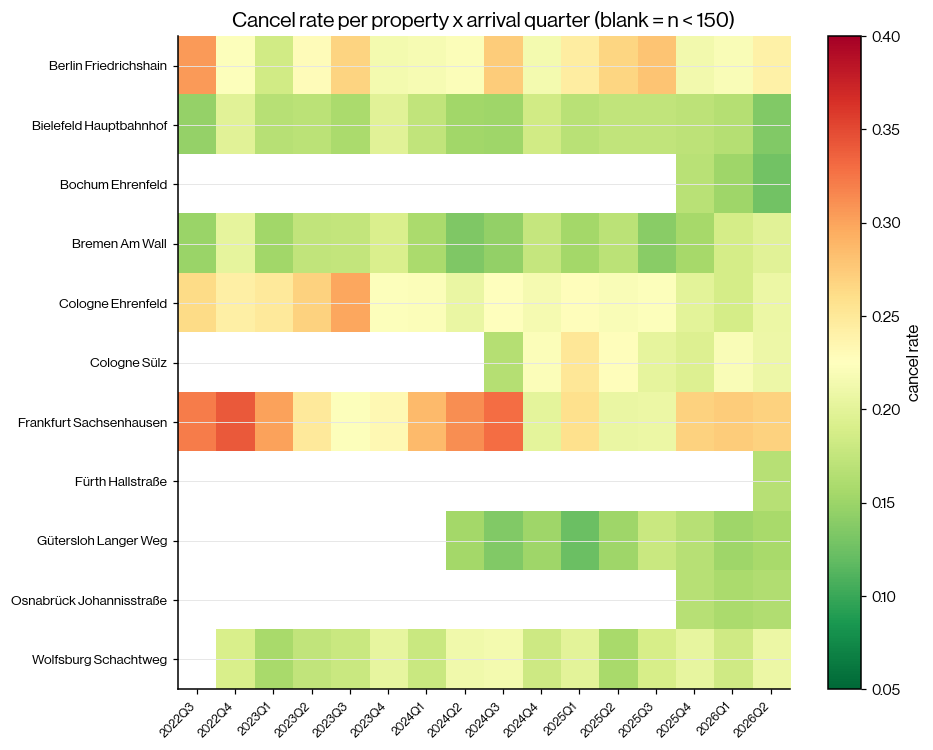

Blank rows at the bottom right = recently opened properties - thin history, expect noisy model slices there (see 01 §10).


In [8]:
#  3) drift view: cancel rate per property x arrival quarter
from src import load_clean_reservations
d = load_clean_reservations().dropna(subset=[TARGET]).copy()
d["quarter"] = pd.PeriodIndex(pd.to_datetime(d["arrival"], utc=True), freq="Q").astype(str)
pt_n = d.pivot_table(index="property_name", columns="quarter", values=TARGET, aggfunc="size")
pt_r = d.pivot_table(index="property_name", columns="quarter", values=TARGET, aggfunc="mean")
pt_r = pt_r.where(pt_n >= 150)        # grey out cells too thin to read (n < 150)
pt_r.to_csv(TAB / "cancel_rate_property_quarter.csv")

fig, ax = plt.subplots(figsize=(max(8, 0.55 * pt_r.shape[1]), 0.45 * pt_r.shape[0] + 2))
im = ax.imshow(pt_r.to_numpy(dtype=float), aspect="auto", cmap="RdYlGn_r",
               vmin=0.05, vmax=0.40)
ax.set_xticks(range(pt_r.shape[1])); ax.set_xticklabels(pt_r.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(pt_r.shape[0])); ax.set_yticklabels(pt_r.index, fontsize=9)
fig.colorbar(im, ax=ax, label="cancel rate")
ax.set_title("Cancel rate per property x arrival quarter (blank = n < 150)")
fig.tight_layout()
fig.savefig(FIG / "cancel_rate_property_quarter.png", dpi=150)
plt.show()
print("Blank rows at the bottom right = recently opened properties - thin history, "
      "expect noisy model slices there (see 01 §10).")


## How to read it

- **Top-deviations chart:** red bars cancel more than average, green less. This is the
  page to hold next to the SHAP beeswarm and compare. If SHAP says something huge that this page calls flat,
  investigate before believing the model.
- **Numeric buckets:** the dashed line is the base rate; the slope tells you direction
  and shape (e.g. lead_time rising = long-lead bookings cancel more).
- **Property x quarter heatmap:** stability check over time and the early-warning view
  for newly opened houses (blank cells = not enough bookings yet).
- All tables are saved to `reports/tables/00_audit/cancel_rate_by_feature_*.csv` for
  reuse in the Streamlit app.
